In [1]:
!pip3 install segmentation_models

In [2]:
import os
os.environ["SM_FRAMEWORK"] = "tf.keras"

In [3]:
import tensorflow as tf
import segmentation_models as sm
import matplotlib.pyplot as plt
import kagglehub
import numpy as np
import albumentations as A
import cv2
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical, Sequence

Segmentation Models: using `tf.keras` framework.


In [4]:
# Download latest version
path = kagglehub.dataset_download("ashish2001/semantic-segmentation-of-underwater-imagery-suim")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'semantic-segmentation-of-underwater-imagery-suim' dataset.
Path to dataset files: /kaggle/input/semantic-segmentation-of-underwater-imagery-suim


In [5]:
BATCH_SIZE = 16
IMG_SIZE = (256, 256)
EPOCHS = 50

color_map = {
    (0, 0, 0): 0,       # background
    (0, 0, 255): 1,     # class 1
    (0, 255, 0): 2,     # class 2
    (0, 255, 255): 3,     # class 3
    (255, 0, 0): 4,     # class 4
    (255, 0, 255): 5,     # class 5
    (255, 255, 0): 6,     # class 6
    (255, 255, 255): 7     # class 7
}

index_to_color = {i: color for color, i in color_map.items()}


In [6]:
def get_augmentation():
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.ShiftScaleRotate(
            shift_limit=0.0625,
            scale_limit=0.1,
            rotate_limit=25,
            interpolation=cv2.INTER_LINEAR,
            mask_interpolation=cv2.INTER_NEAREST,
            p=0.5
        ),
        A.GridDistortion(
            num_steps=5,
            distort_limit=0.3,
            interpolation=cv2.INTER_LINEAR,
            mask_interpolation=cv2.INTER_NEAREST,
            p=0.2
        ),
        A.RandomBrightnessContrast(
            brightness_limit=0.2,
            contrast_limit=0.2,
            p=0.3
        )
    ], additional_targets={'mask': 'image'})

def load_data(dir):
    image_paths = []
    mask_paths = []
    
    for filename in os.listdir(os.path.join(dir, "images")):
        if filename.endswith(".jpg"):
            base_name = os.path.splitext(filename)[0]
            img_path = os.path.join(dir, "images", filename)
            mask_path = os.path.join(dir, "masks", base_name + ".bmp")
            
            if os.path.exists(mask_path):
                image_paths.append(img_path)
                mask_paths.append(mask_path)
    
    return image_paths, mask_paths

In [7]:
class SUIMGenerator(Sequence):
    def __init__(self, image_paths, mask_paths, batch_size=BATCH_SIZE, image_size=IMG_SIZE, augmentations=None, preprocess=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.batch_size = batch_size
        self.image_size = image_size
        self.augmentations = augmentations
        self.colors = np.array(list(color_map.keys()))
        self.num_classes = len(color_map)
        self.preprocess = preprocess

    def __len__(self):
        return int(np.ceil(len(self.image_paths) / self.batch_size))

    def __getitem__(self, idx):
        # Формируем индексы для текущего батча
        batch_x_paths = self.image_paths[idx * self.batch_size : (idx + 1) * self.batch_size]
        batch_y_paths = self.mask_paths[idx * self.batch_size : (idx + 1) * self.batch_size]

        batch_images = []
        batch_masks = []

        for img_path, mask_path in zip(batch_x_paths, batch_y_paths):
            # Чтение (лучше делать ресайз сразу при чтении, если возможно)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, self.image_size)
            
            mask = cv2.imread(mask_path)
            mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
            mask = cv2.resize(mask, self.image_size, interpolation=cv2.INTER_NEAREST)

            # Аугментация
            if self.augmentations:
                augmented = self.augmentations(image=img, mask=mask)
                img, mask = augmented['image'], augmented['mask']

            # Оптимизированный перевод RGB -> Index
            class_mask = np.zeros(mask.shape[:2], dtype=np.uint8)
            for i, color in enumerate(self.colors):
                class_mask[np.all(mask == color, axis=-1)] = i
            
            img = self.preprocess(img)
            
            batch_images.append(img)
            batch_masks.append(to_categorical(class_mask, num_classes=self.num_classes))

        return np.array(batch_images, dtype='float32'), np.array(batch_masks, dtype='float32')

    def on_epoch_end(self):
        # Перемешивание данных после каждой эпохи
        combined = list(zip(self.image_paths, self.mask_paths))
        np.random.shuffle(combined)
        self.image_paths, self.mask_paths = zip(*combined)


In [8]:
def predict(model, img, gt):

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,5))

    def decode_mask(mask):
        # mask shape: (256, 256, 8)
        class_indices = np.argmax(mask, axis=-1)
        print(class_indices)
        decoded_mask = np.zeros((class_indices.shape[0], class_indices.shape[1], 3), dtype=np.uint8)
        
        for idx, color in index_to_color.items():
            decoded_mask[class_indices == idx] = color
        
        return decoded_mask

    mask = model.predict(tf.expand_dims(img, axis=0))

    decoded_mask = decode_mask(mask[0])

    ax1.imshow(decoded_mask)
    ax2.imshow(gt)
    plt.show()

In [9]:
train_path = os.path.join(path, "train_val")

train_image_paths, train_mask_paths = load_data(train_path)

train_img, val_img, train_mask, val_mask = train_test_split(train_image_paths, train_mask_paths, test_size=0.2, random_state=42)

train_steps = len(train_img)
val_steps = len(val_img)

In [10]:
test_path = os.path.join(path, 'TEST')

test_imgs = [img for img in os.listdir(os.path.join(test_path, 'images'))]

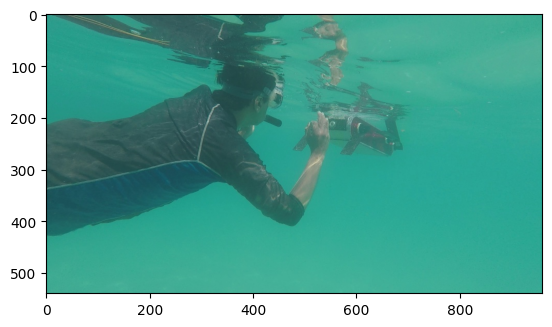

In [11]:
test_img = cv2.imread(os.path.join(test_path, 'images', test_imgs[0]))

test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)

plt.imshow(test_img)

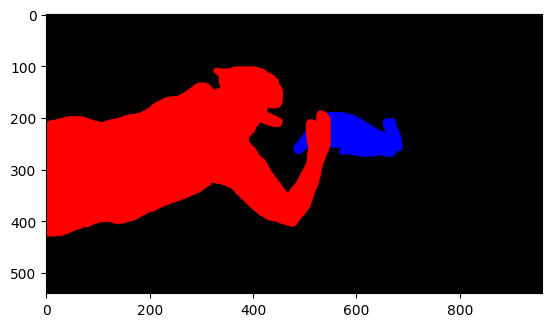

In [12]:
base_name = os.path.splitext(test_imgs[0])

test_mask= cv2.imread(os.path.join(test_path, 'masks', base_name[0] + ".bmp"))

plt.imshow(test_mask)

In [13]:
NEW_BACKBONE = 'resnet50'

model_resnet = sm.Unet(NEW_BACKBONE,
                        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
                        classes=len(color_map),
                        activation='softmax',
                        encoder_freeze=True)

dice_loss = sm.losses.DiceLoss()

cross_entropy_loss = sm.losses.CategoricalCELoss()

total_loss = cross_entropy_loss + dice_loss

metrics = [sm.metrics.IOUScore(threshold=None), sm.metrics.FScore()]

model_resnet.compile(optimizer=tf.keras.optimizers.Adam(1e-4), 
              loss=total_loss, 
              metrics=metrics)

preprocess_input = sm.get_preprocessing(NEW_BACKBONE)

train_gen = SUIMGenerator(train_img, train_mask, augmentations=get_augmentation(), preprocess=preprocess_input)
val_gen = SUIMGenerator(val_img, val_mask, preprocess=preprocess_input)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint('./best_model_resnet50_transfer.keras', save_best_only=True, monitor='val_iou_score', mode='max'),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

# Компилируем модель с обычным lr для обучения декодера
model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4), 
    loss=total_loss, 
    metrics=metrics
)

# Обучение только декодера
history_stage1 = model_resnet.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)



/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 153s 1s/step - f1-score: 0.1088 - iou_score: 0.0616 - loss: 1.1566 - val_f1-score: 0.1477 - val_iou_score: 0.0851 - val_loss: 1.0625 - learning_rate: 1.0000e-04
Epoch 2/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 42s 547ms/step - f1-score: 0.2096 - iou_score: 0.1293 - loss: 0.9785 - val_f1-score: 0.2283 - val_iou_score: 0.1414 - val_loss: 0.9425 - learning_rate: 1.0000e-04
Epoch 3/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 42s 550ms/step - f1-score: 0.2781 - iou_score: 0.1800 - loss: 0.8825 - val_f1-score: 0.2790 - val_iou_score: 0.1814 - val_loss: 0.8644 - learning_rate: 1.0000e-04
Epoch 4/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 42s 546ms/step - f1-score: 0.3309 - iou_score: 0.2234 - loss: 0.8135 - val_f1-score: 0.3409 - val_iou_score: 0.2310 - val_loss: 0.7828 - learning_rate: 1.0000e-04
Epoch 5/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 42s 551ms/step - f1-score: 0.3419 - iou_score: 0.2326 - loss: 0.8025 - val_f1-score: 0.3630 - val_iou_score: 0.2550 - val_loss: 0.7473 - learning_rate: 1.0000e-

In [14]:
model_resnet.save_weights("./model.weights.h5")

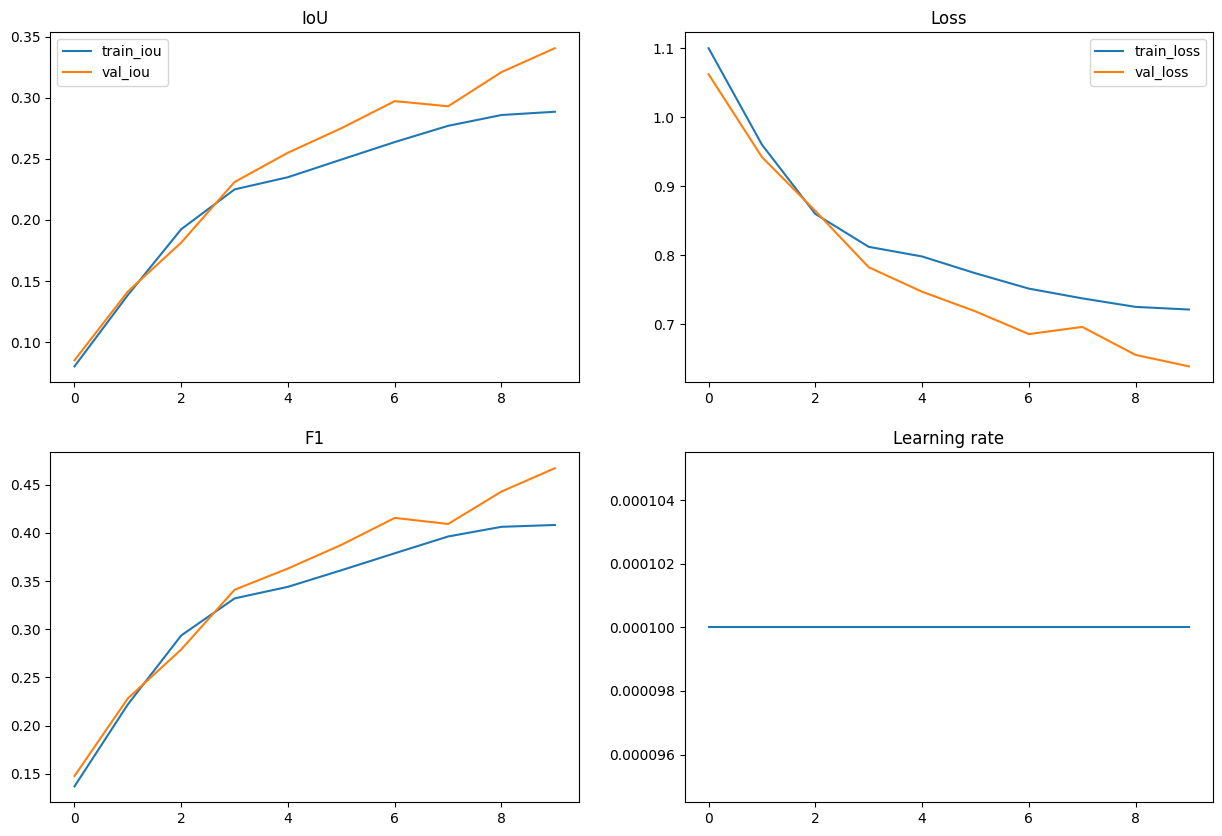

In [15]:
hist = history_stage1.history
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
ax1.set_title('IoU')
ax2.set_title('Loss')
ax3.set_title('F1')
ax4.set_title('Learning rate')
ax1.plot(hist['iou_score'], label='train_iou')
ax1.plot(hist['val_iou_score'], label='val_iou')
ax2.plot(hist['loss'], label='train_loss')
ax2.plot(hist['val_loss'], label='val_loss')
ax3.plot(hist['f1-score'], label='train_f1')
ax3.plot(hist['val_f1-score'], label='val_f1')
ax4.plot(hist['learning_rate'])
ax1.legend()
ax2.legend()
plt.show()

In [16]:
model_resnet = sm.Unet(NEW_BACKBONE,
                        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
                        classes=len(color_map),
                        activation='softmax',
                        weights="model.weights.h5")

# Компилируем модель снова с меньшим learning rate
model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=total_loss,
    metrics=metrics
)

# Продолжаем обучение всей модели
history_stage2 = model_resnet.fit(
    train_gen,
    epochs=EPOCHS - 10,  # общее количество эпох, или еще 20-30 после первых 10
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/40
77/77 ━━━━━━━━━━━━━━━━━━━━ 125s 955ms/step - f1-score: 0.4262 - iou_score: 0.3022 - loss: 0.6978 - val_f1-score: 0.4825 - val_iou_score: 0.3597 - val_loss: 0.6070 - learning_rate: 1.0000e-05
Epoch 2/40
77/77 ━━━━━━━━━━━━━━━━━━━━ 44s 576ms/step - f1-score: 0.4074 - iou_score: 0.2880 - loss: 0.7186 - val_f1-score: 0.4959 - val_iou_score: 0.3717 - val_loss: 0.6006 - learning_rate: 1.0000e-05
Epoch 3/40
77/77 ━━━━━━━━━━━━━━━━━━━━ 43s 564ms/step - f1-score: 0.4484 - iou_score: 0.3211 - loss: 0.6731 - val_f1-score: 0.4990 - val_iou_score: 0.3749 - val_loss: 0.5942 - learning_rate: 1.0000e-05
Epoch 4/40
77/77 ━━━━━━━━━━━━━━━━━━━━ 43s 560ms/step - f1-score: 0.4554 - iou_score: 0.3280 - loss: 0.6680 - val_f1-score: 0.5081 - val_iou_score: 0.3839 - val_loss: 0.5824 - learning_rate: 1.0000e-05
Epoch 5/40
77/77 ━━━━━━━━━━━━━━━━━━━━ 44s 570ms/step - f1-score: 0.4464 - iou_score: 0.3243 - loss: 0.6704 - val_f1-score: 0.5205 - val_iou_score: 0.3941 - val_loss: 0.5718 - learning_rate: 1.000

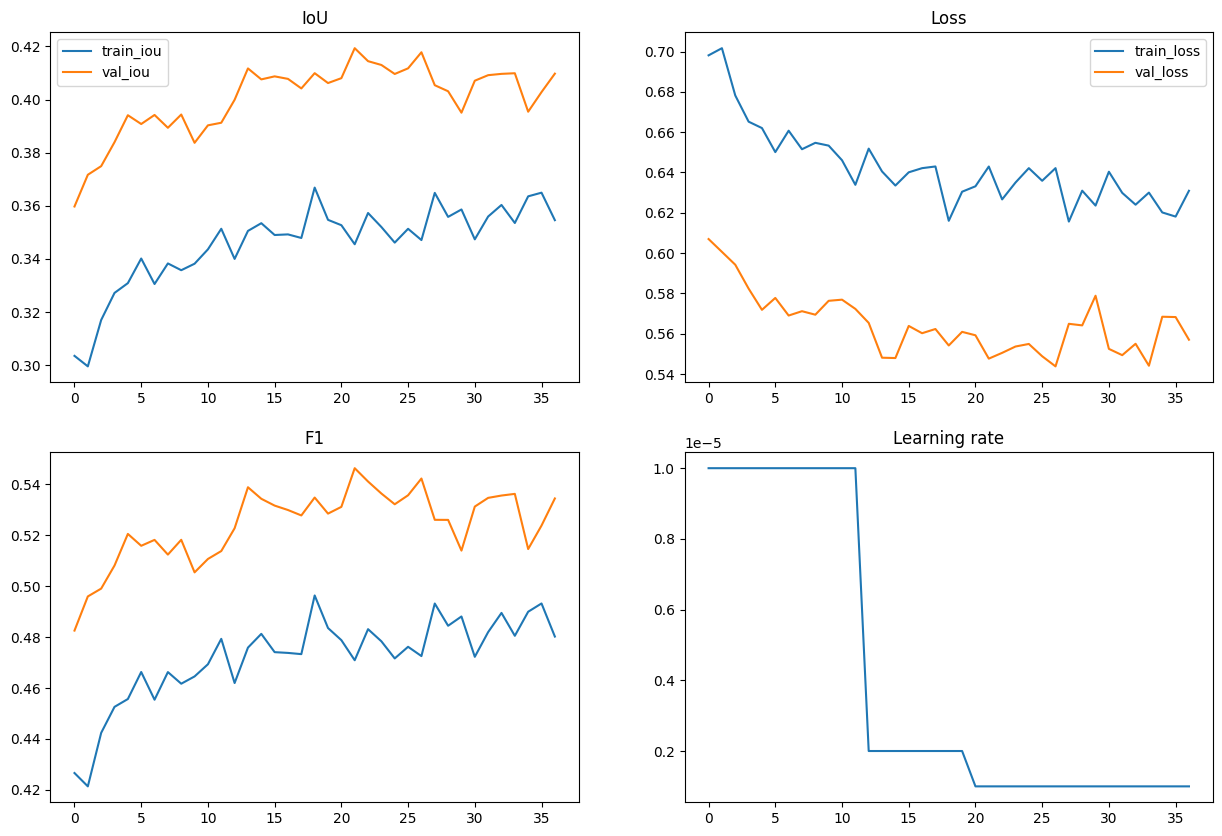

In [17]:
hist = history_stage2.history
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
ax1.set_title('IoU')
ax2.set_title('Loss')
ax3.set_title('F1')
ax4.set_title('Learning rate')
ax1.plot(hist['iou_score'], label='train_iou')
ax1.plot(hist['val_iou_score'], label='val_iou')
ax2.plot(hist['loss'], label='train_loss')
ax2.plot(hist['val_loss'], label='val_loss')
ax3.plot(hist['f1-score'], label='train_f1')
ax3.plot(hist['val_f1-score'], label='val_f1')
ax4.plot(hist['learning_rate'])
ax1.legend()
ax2.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


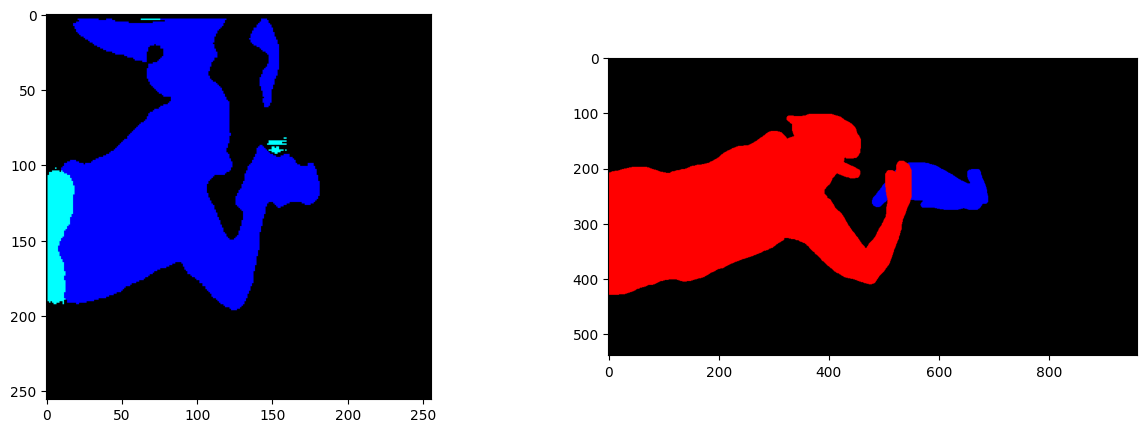

In [18]:
test_img = preprocess_input(test_img)
test_img = cv2.resize(test_img, IMG_SIZE)

predict(model_resnet, test_img, test_mask)